DOWLOAD ALL THE REQUIRED LIBRARIES

In [ ]:
!pip install diffusers transformers accelerate matplotlib -q

IMPORTING THE LIBRARIES

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


CONNECTION TO THE GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


dataset_path = "/content/drive/MyDrive/MRI_Project/better_slices"

checkpoint_path = "/content/drive/MyDrive/MRI_Project/conditional_mri_checkpoint.pth"

print("Files found:", len([f for f in os.listdir(dataset_path) if f.endswith(".png")]))

Mounted at /content/drive
Files found: 5599


DATASET

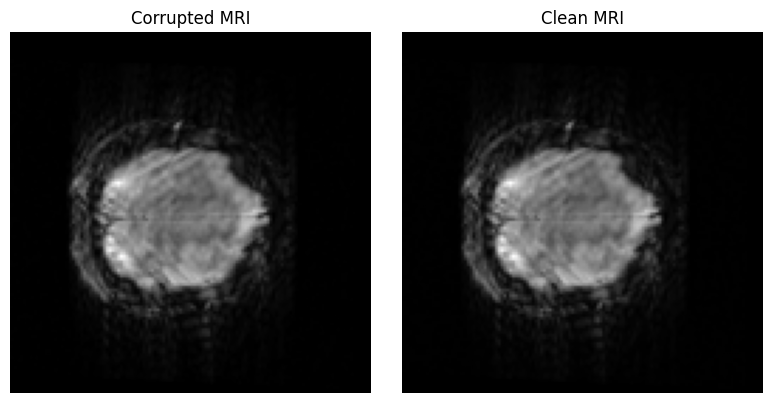

Dataset size: 5599 images | Steps per epoch: 700


In [ ]:
class ConditionalMRIDataset(Dataset):

    def __init__(self, folder_path):
        self.image_files = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.endswith(".png")
        ]
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])   # maps [0,1] → [-1,1]
        ])

    def add_motion_artifact(self, image):
        """Simulate MRI motion artifact via k-space (frequency domain) corruption."""
        kspace = torch.fft.fft2(image)

        # Corrupt 30% of phase-encode lines (mimics head motion during scan)
        num_corrupted = int(0.3 * kspace.shape[-2])
        lines = torch.randperm(kspace.shape[-2])[:num_corrupted]
        kspace[:, lines, :] += torch.randn_like(kspace[:, lines, :]) * 0.3

        corrupted = torch.fft.ifft2(kspace).real
        return torch.clamp(corrupted, -1, 1)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx])
        clean = self.transform(image)
        corrupted = self.add_motion_artifact(clean)
        return corrupted, clean


# Quick sanity check — visualise one pair
dataset = ConditionalMRIDataset(dataset_path)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

corrupted_sample, clean_sample = dataset[0]
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(corrupted_sample.squeeze(), cmap="gray")
ax[0].set_title("Corrupted MRI"); ax[0].axis("off")
ax[1].imshow(clean_sample.squeeze(), cmap="gray")
ax[1].set_title("Clean MRI"); ax[1].axis("off")
plt.tight_layout(); plt.show()
print(f"Dataset size: {len(dataset)} images | Steps per epoch: {len(dataloader)}")

U-NET MODEL, SCHEDULER AND OPTIMIZER

In [ ]:
model = UNet2DModel(
    sample_size=128,
    in_channels=2,        # channel 0: noisy clean image | channel 1: corrupted MRI (conditioning)
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",   # attention at the middle scale
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to("cuda")

noise_scheduler = DDPMScheduler(num_train_timesteps=200)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {total_params:.1f}M")


Model parameters: 3.7M


LOADING CHECKPOINTS IF THEY EXIST

In [ ]:
start_epoch = 0

if os.path.exists(checkpoint_path):
    print("Checkpoint found — loading...")
    checkpoint = torch.load(checkpoint_path, map_location="cuda")
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found — starting fresh.")

No checkpoint found — starting fresh.


TRAINING LOOP

In [ ]:
epochs = 20   # ~14,000 steps total; aim for loss < 0.05

model.train()

for epoch in range(start_epoch, epochs):
    epoch_loss = 0.0

    for step, (corrupted_images, clean_images) in enumerate(dataloader):
        corrupted_images = corrupted_images.to("cuda")
        clean_images     = clean_images.to("cuda")

        # 1. Sample random noise
        noise = torch.randn_like(clean_images)

        # 2. Sample random timesteps for each image in the batch
        timesteps = torch.randint(
            0, 200, (clean_images.shape[0],), device="cuda"
        ).long()

        # 3. Forward diffusion — add noise to clean images
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # 4. ✅ Concatenate corrupted MRI as conditioning channel
        model_input = torch.cat([noisy_images, corrupted_images], dim=1)  # [B, 2, 128, 128]

        # 5. Predict the noise
        noise_pred = model(model_input, timesteps).sample

        # 6. Loss = how wrong was the noise prediction
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch+1:>3}/{epochs} | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint to Drive every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, checkpoint_path)
    print(f"  └─ Epoch {epoch+1} checkpoint saved → {checkpoint_path}")

print("\nTraining complete!")


Epoch   1/20 | Avg Loss: 0.0595
Epoch   2/20 | Avg Loss: 0.0093
Epoch   3/20 | Avg Loss: 0.0050
Epoch   4/20 | Avg Loss: 0.0040
Epoch   5/20 | Avg Loss: 0.0033
  └─ Checkpoint saved → /content/drive/MyDrive/MRI_Project/conditional_mri_checkpoint.pth
Epoch   6/20 | Avg Loss: 0.0028


INFERENCE (ITERATIVE DDIM DENOISING)

In [ ]:
model.eval()

# Pick any index from the dataset to test
test_idx = 0
corrupted_image, clean_image = dataset[test_idx]
corrupted_input = corrupted_image.unsqueeze(0).to("cuda")   # [1, 1, 128, 128]

# DDIM scheduler — same T=200 as training, but only 50 inference steps
inference_scheduler = DDIMScheduler(num_train_timesteps=200)
inference_scheduler.set_timesteps(50)

# Start from pure Gaussian noise (standard DDPM/DDIM starting point)
x = torch.randn_like(corrupted_input)

with torch.no_grad():
    for t in inference_scheduler.timesteps:          # iterates 199 → 0 in 50 steps
        t_batch     = torch.tensor([t], device="cuda")
        model_input = torch.cat([x, corrupted_input], dim=1)
        noise_pred  = model(model_input, t_batch).sample
        x           = inference_scheduler.step(noise_pred, t, x).prev_sample

# Denormalise from [-1, 1] back to [0, 1] for display
reconstructed = (x.squeeze().cpu().numpy() * 0.5) + 0.5


VISUALIZATION OF THE RESULT

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

ax[0].imshow(corrupted_image.squeeze(), cmap="gray")
ax[0].set_title("Corrupted MRI (Input)"); ax[0].axis("off")

ax[1].imshow(reconstructed, cmap="gray")
ax[1].set_title("Reconstructed MRI (Model Output)"); ax[1].axis("off")

ax[2].imshow(clean_image.squeeze(), cmap="gray")
ax[2].set_title("Ground Truth"); ax[2].axis("off")

plt.suptitle("Conditional Diffusion Model — MRI Artifact Removal", fontsize=13)
plt.tight_layout()
plt.show()

MATHEMATICAL EVALUATION OF THE MODEL

In [ ]:
!pip install scikit-image
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

In [ ]:
import numpy as np

# CLEAN IMAGE
ground_truth = clean_image.squeeze().cpu().numpy()

# RECONSTRUCTED IMAGE
reconstructed_eval = reconstructed.squeeze().cpu().numpy()

# NORMALIZE BOTH
ground_truth = (ground_truth + 1) / 2
reconstructed_eval = (reconstructed_eval + 1) / 2

# CLIP VALUES
ground_truth = np.clip(
    ground_truth,
    0,
    1
)

reconstructed_eval = np.clip(
    reconstructed_eval,
    0,
    1
)

# MSE
mse_value = mean_squared_error(
    ground_truth,
    reconstructed_eval
)

# PSNR
psnr_value = peak_signal_noise_ratio(
    ground_truth,
    reconstructed_eval,
    data_range=1.0
)

# SSIM
ssim_value = structural_similarity(
    ground_truth,
    reconstructed_eval,
    data_range=1.0
)

print(f"MSE  : {mse_value:.4f}")
print(f"PSNR : {psnr_value:.4f}")
print(f"SSIM : {ssim_value:.4f}")